### K Means Clustering Algorithms

In [231]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [232]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [233]:
X.shape

(1000, 2)

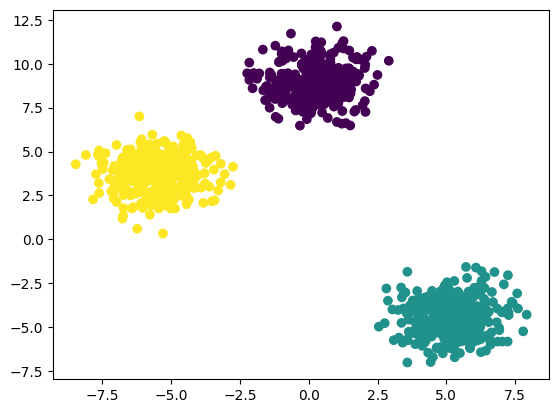

In [234]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [235]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [236]:
## Manual Process
## Elbow method to select the K value

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

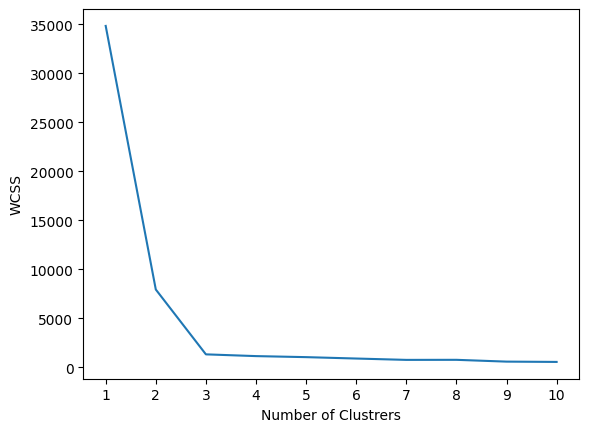

In [237]:
## plot elbow curve
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [238]:
kmeans = KMeans(n_clusters=3, init="k-means++")
y_labels = kmeans.fit_predict(X_train)
y_test_labels = kmeans.predict(X_test)
y_test_labels

array([0, 0, 0, 1, 2, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0,
       1, 0, 0, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 0,
       1, 2, 1, 0, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 1,
       1, 0, 2, 2, 0, 0, 2, 1, 1, 0, 1, 1, 0, 0, 2, 2, 1, 2, 1, 1, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 1, 1,
       2, 2, 1, 2, 1, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 1, 2, 0, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 1, 0, 0, 2, 2, 2, 0, 2, 2, 1, 1, 1, 1, 0, 2, 2, 0,
       0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0, 2, 0, 0, 2, 2,
       2, 1, 1, 0, 1, 2, 1, 0, 2, 2, 1, 2, 1, 0, 2, 1, 2, 2, 2, 1, 2, 2,
       1, 1, 0, 0, 1, 0, 1, 2, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2,
       1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 1, 0, 2, 0,
       0, 2, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 2, 0, 1, 1, 2, 1, 2, 2, 2, 1, 0, 2, 0, 2, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 0,

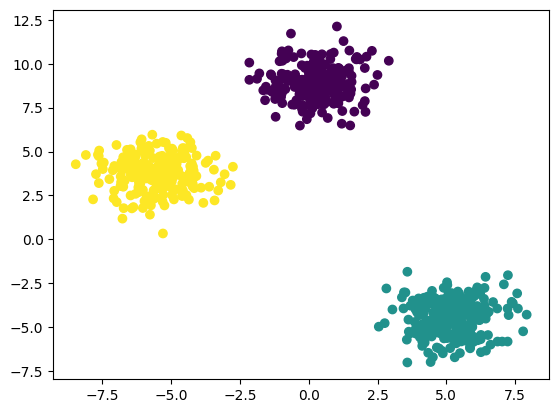

In [239]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_labels)

In [240]:
## Knee Locator
kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
kl.elbow

np.int64(3)

In [241]:
## Performance Metrics
## Silhouette Score
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficients.append(score)

In [242]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6505454471731087,
 0.6557491718803581,
 0.29466568787068714,
 0.3425105292800712,
 0.3421299774199064,
 0.32241497308124123,
 0.3328177678869427]

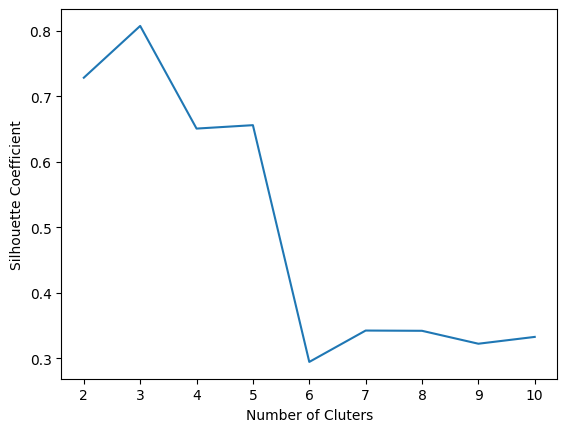

In [243]:
## Plotting Silhouette Score
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhouette Coefficient")
plt.show()